In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../data/raw/loan.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df.shape

(614, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


- ApplicantIncome is highly right-skewed
    - Mean   = 5403
    - Median = 3812
    - Max    = 81000

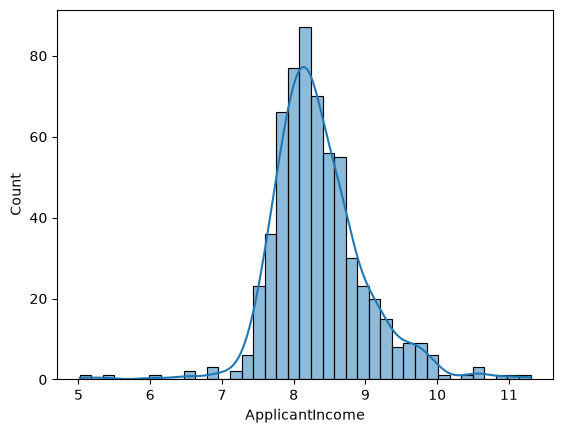

In [21]:
sns.histplot(np.log1p(df["ApplicantIncome"]), kde=True)
plt.show()

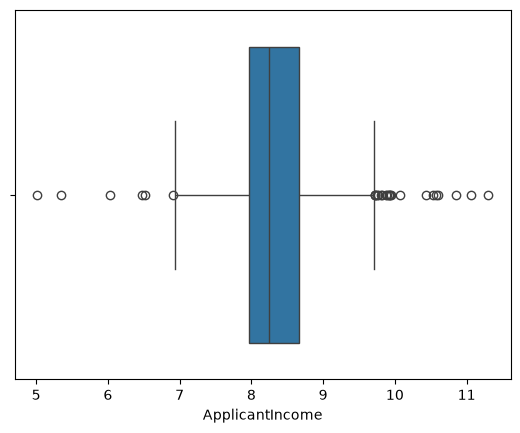

In [22]:
sns.boxplot(x=np.log1p(df["ApplicantIncome"]))
plt.show()

In [23]:
(df["CoapplicantIncome"] == 0).mean() * 100

np.float64(44.462540716612374)

- A significant proportion of applicants have no co-applicant income, indicating many single-income loan applications.

In [27]:
print(df['LoanAmount'].isna().sum())

22


In [28]:
# percentage of missing value in LoanAmount
(22/614)*100

3.5830618892508146

In [29]:
# percentage of missing value in Gender
(13/614)*100

2.1172638436482085

In [30]:
# percentage of missing value in Married
(3/614)*100

0.4885993485342019

In [31]:
# percentage of missing value in Dependents
(15/614)*100


2.44299674267101

In [32]:
# percentage of missing value in Self_Employed
((614-582)/614)*100


5.211726384364821

In [33]:
# percentage of missing value in Loan_Amount_Term
(14/614)*100


2.2801302931596092

In [34]:
# percentage of missing value in Credit_History
((614-564)/614)*100


8.143322475570033

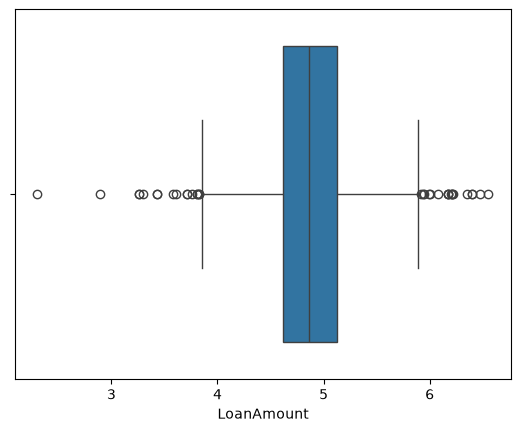

In [36]:
sns.boxplot(x=np.log1p(df["LoanAmount"]))
plt.show()

- Since Credit_History
- 0 = Poor history
- 1 = Good history

In [43]:
df['Credit_History'].value_counts(normalize=True)*100

Credit_History
1.0    84.219858
0.0    15.780142
Name: proportion, dtype: float64

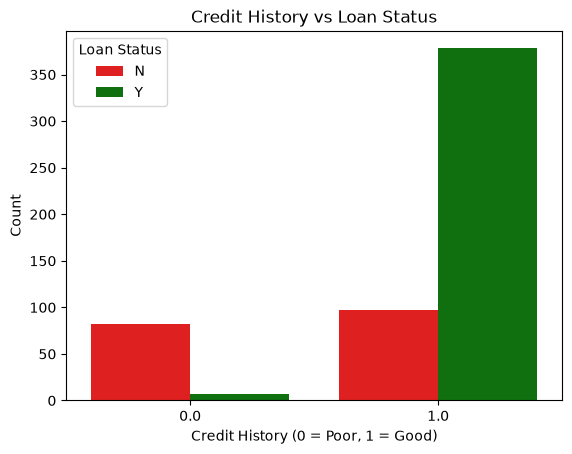

In [56]:
sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status',
    palette=['red', 'green']
)

plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History (0 = Poor, 1 = Good)')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.show()

In [57]:
pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


In [58]:
df['Loan_Status'].value_counts(normalize=True)*100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

- slightly imbalanced data , we have to use stratify so: Metrics such as Precision, Recall, F1-score, and ROC-AUC are more informative than Accuracy alone.

In [62]:
df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].median()
)

In [63]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median( ))

In [71]:
X = df.drop(columns=['Loan_Status'],axis=1)
Y=df['Loan_Status']

In [75]:
categorical_cols = [
    col for col in X.columns
    if X[col].dtype == 'object'
]
   

In [78]:
for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [76]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [80]:
categorical_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']